In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings 
warnings.filterwarnings('ignore')

In [8]:
df=pd.read_csv('C:\\Users\\pritp\\Desktop\\ford car price prediction\\data\\ford.csv')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [9]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [10]:
df.shape

(17966, 9)

In [11]:
print('-------information of dataset---------\n')
df.info()

-------information of dataset---------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [12]:
print('description of dataset\n')
df.describe()

description of dataset



,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [13]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [14]:
df['year'].value_counts()

year
2017    4888
2018    4014
2019    3194
2016    2331
2015    1368
2014     805
2013     609
2020     258
2012     115
2011      94
2009      91
2010      67
2008      57
2007      32
2005      16
2006      13
2004       4
2003       3
2002       3
1998       1
1996       1
2000       1
2060       1
Name: count, dtype: int64

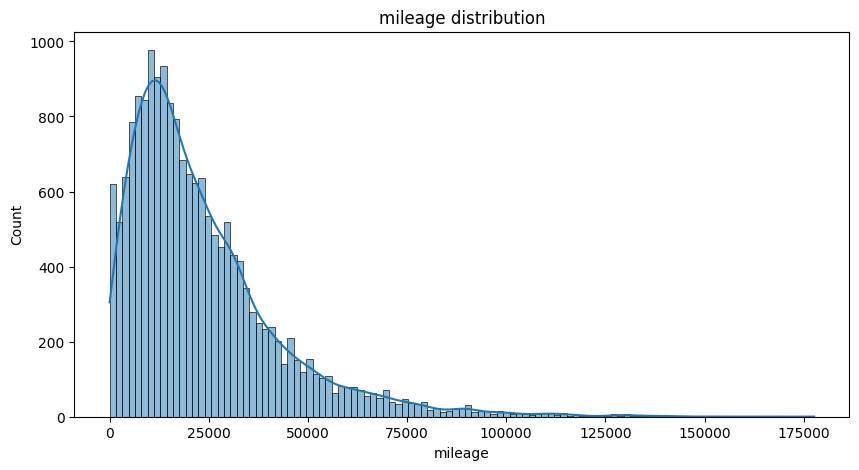

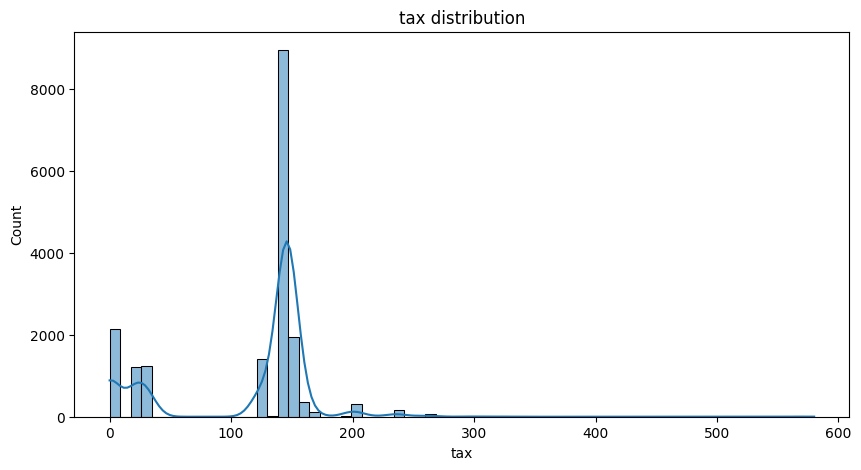

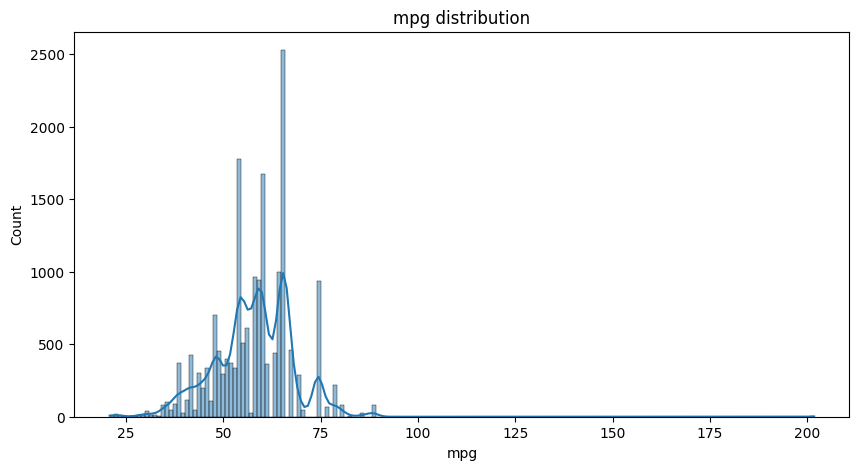

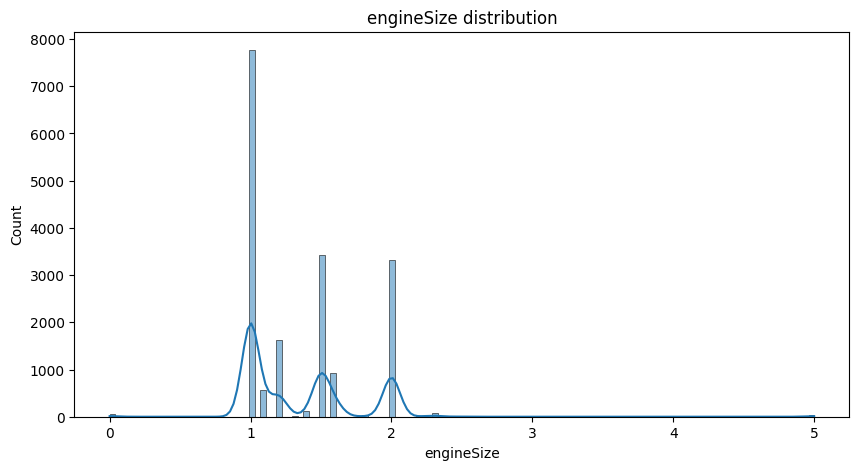

In [15]:
numeric_column=df[['mileage','tax','mpg','engineSize']]
for i in numeric_column:
    plt.figure(figsize=(10,5))
    sns.histplot(df[i],kde=True)
    plt.title(f'{i} distribution')
    plt.show()

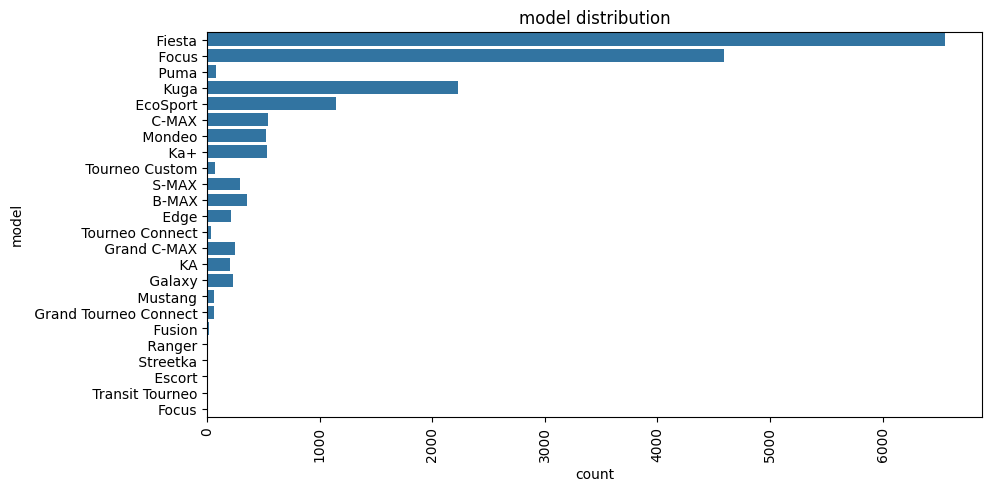

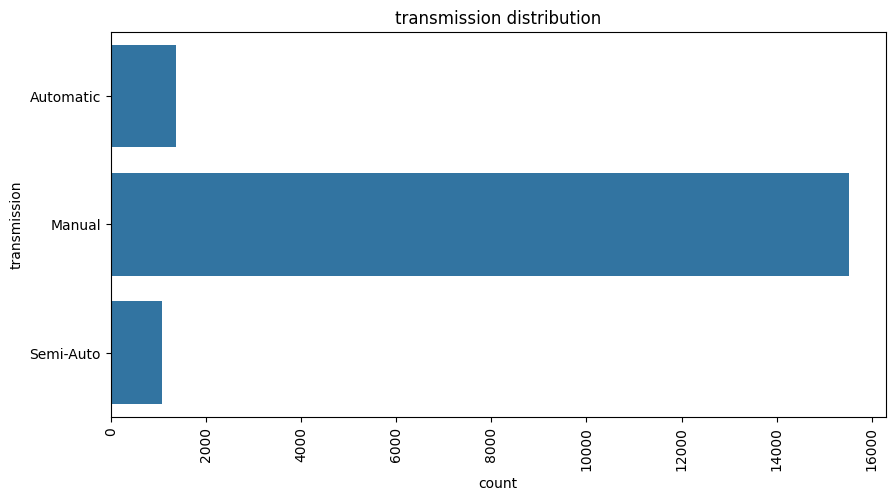

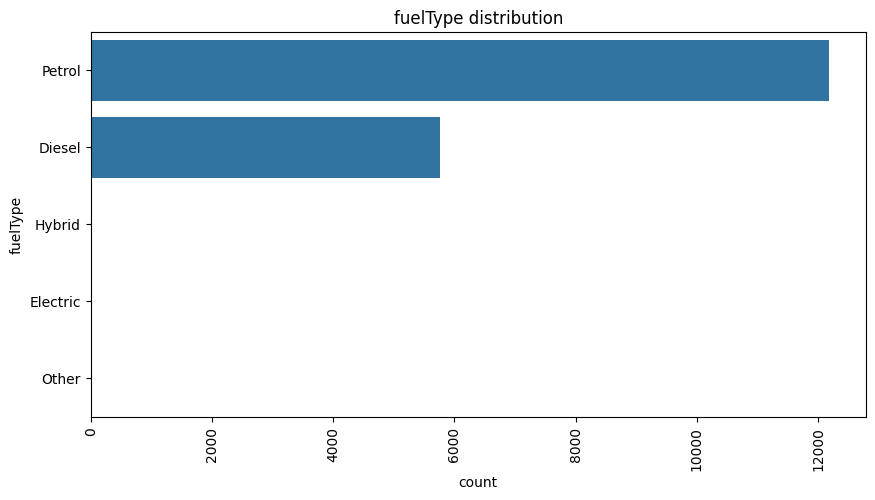

In [16]:
cat_column=df[['model','transmission','fuelType']]
for i in cat_column:
    plt.figure(figsize=(10,5))
    sns.countplot(df[i])
    plt.xticks(rotation=90)
    plt.title(f'{i} distribution')
    plt.show()

Text(0.5, 1.0, 'mileage vs price')

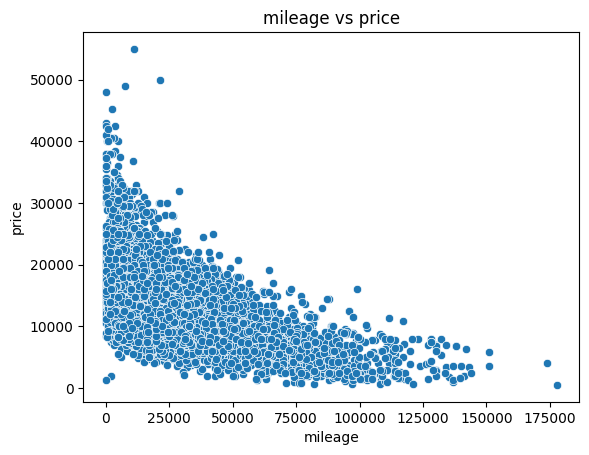

In [17]:
sns.scatterplot(x=df['mileage'],y=df['price'])
plt.title('mileage vs price')

Text(0.5, 1.0, 'tax vs price')

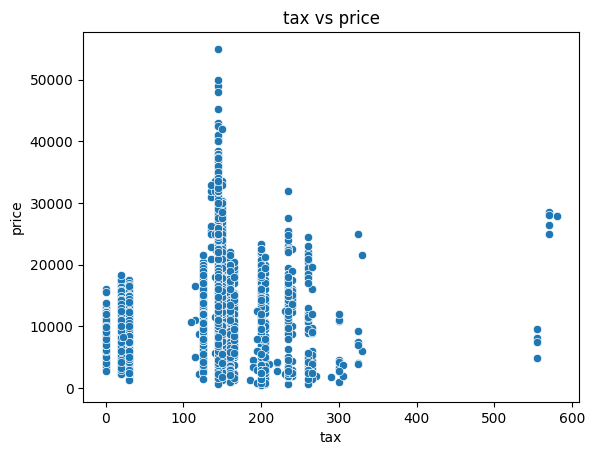

In [18]:
sns.scatterplot(x=df['tax'],y=df['price'])
plt.title('tax vs price')

In [19]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

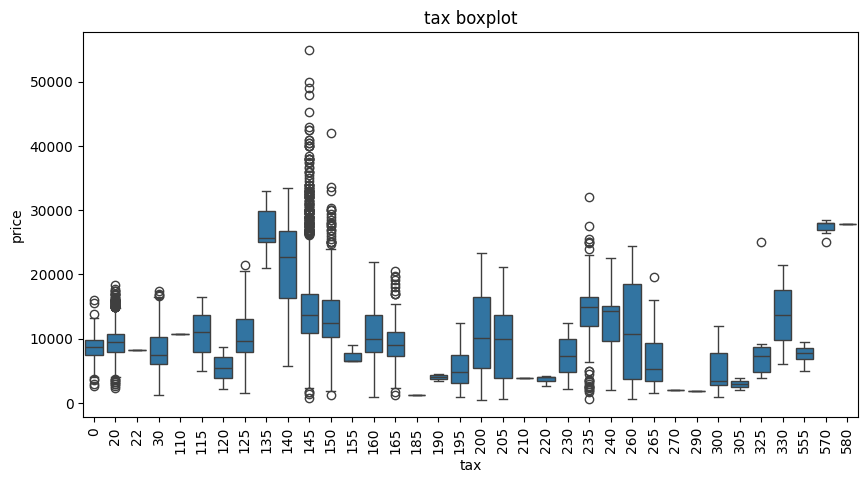

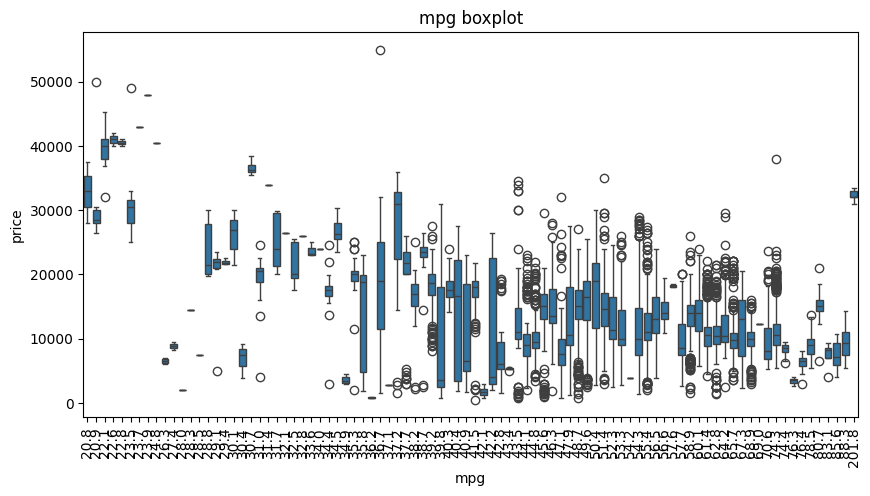

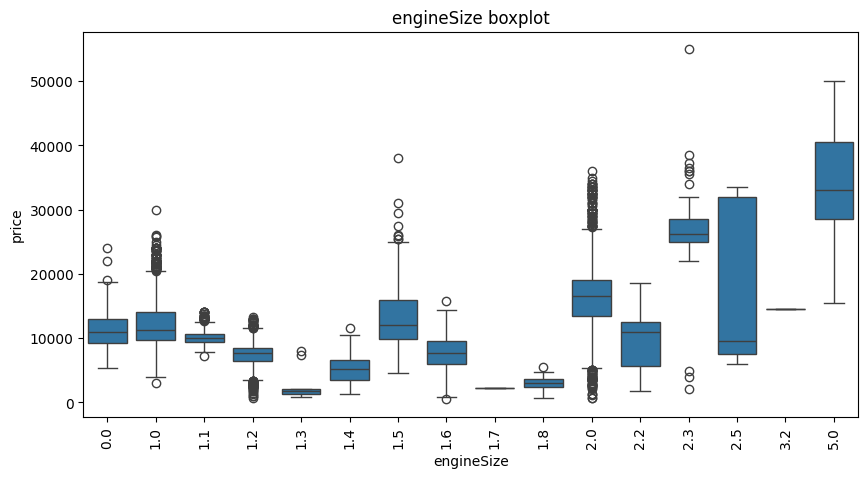

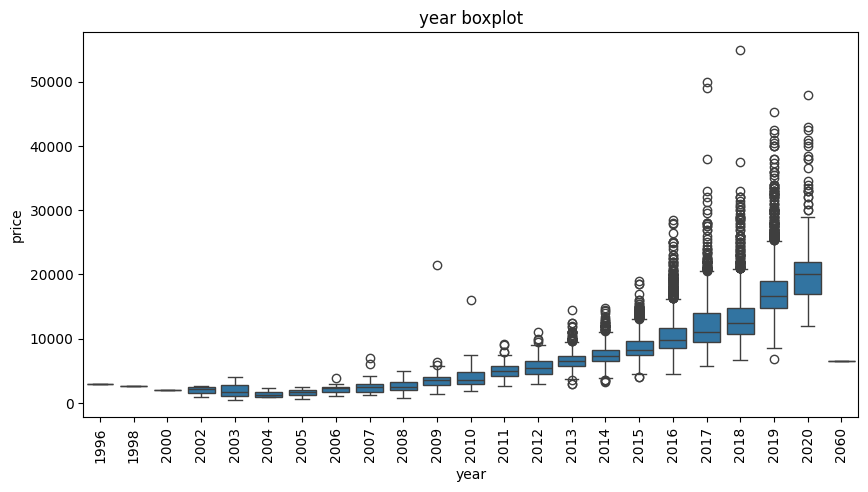

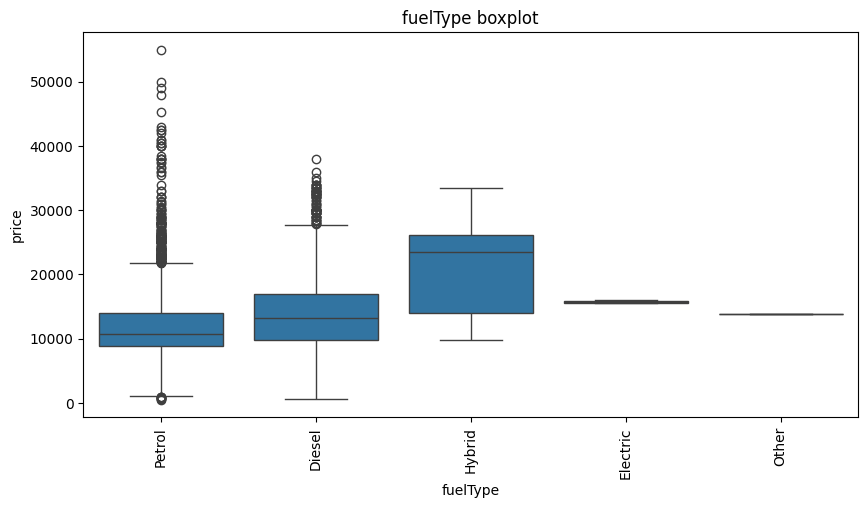

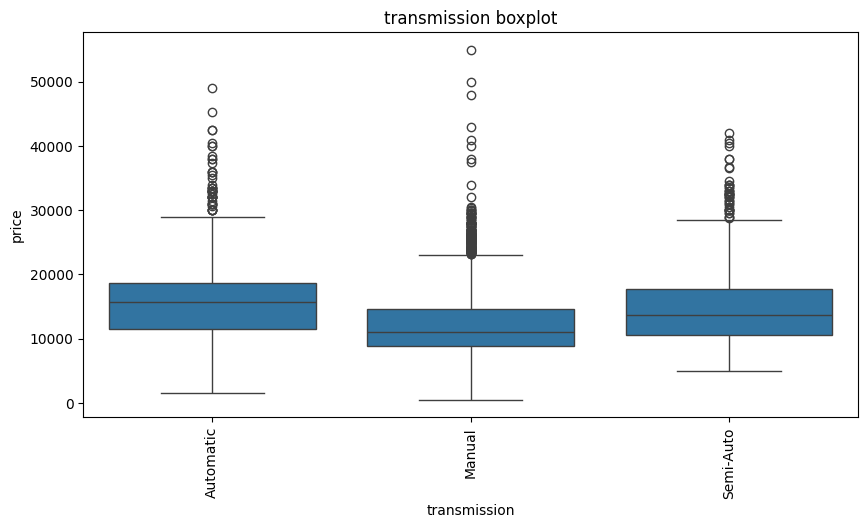

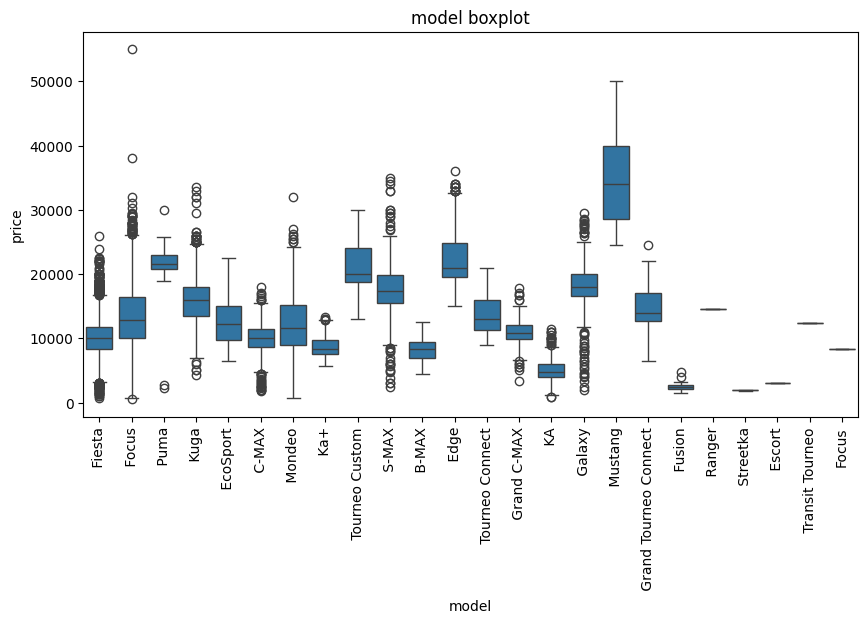

In [20]:
box_df=df[['tax','mpg','engineSize','year','fuelType','transmission','model']]
for i in box_df:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=box_df[i],y=df['price'])
    plt.xticks(rotation=90)
    plt.title(f'{i} boxplot')
    plt.show()

<Axes: >

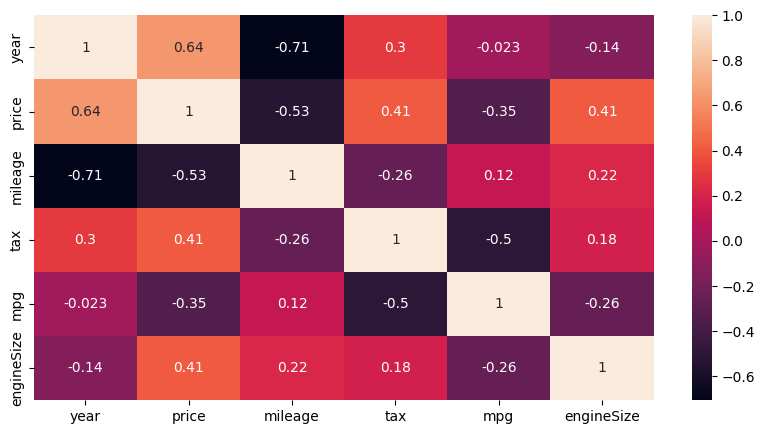

In [21]:
correlation=df.corr(numeric_only=True)
plt.figure(figsize=(10,5))
sns.heatmap(correlation,annot=True)

In [22]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
# Fix categorical encoding (previous assignment to a single column can fail)
X = df.drop('price', axis=1).copy()
y = df['price'].copy()

X['model'] = le.fit_transform(X['model'])
X = pd.get_dummies(X, columns=['transmission', 'fuelType'], drop_first=True)


print(X.head())

   model  year  mileage  tax   mpg  engineSize  transmission_Manual  \
0      5  2017    15944  150  57.7         1.0                False   
1      6  2018     9083  150  57.7         1.0                 True   
2      6  2017    12456  150  57.7         1.0                 True   
3      5  2019    10460  145  40.3         1.5                 True   
4      5  2019     1482  145  48.7         1.0                False   

   transmission_Semi-Auto  fuelType_Electric  fuelType_Hybrid  fuelType_Other  \
0                   False              False            False           False   
1                   False              False            False           False   
2                   False              False            False           False   
3                   False              False            False           False   
4                   False              False            False           False   

   fuelType_Petrol  
0             True  
1             True  
2             True  
3 

In [23]:
# Convert all boolean columns in X to integer (False->0, True->1)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

X.head()

,model,year,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,5,2017,15944,150,57.7,1.0,0,0,0,0,0,1
1,6,2018,9083,150,57.7,1.0,1,0,0,0,0,1
2,6,2017,12456,150,57.7,1.0,1,0,0,0,0,1
3,5,2019,10460,145,40.3,1.5,1,0,0,0,0,1
4,5,2019,1482,145,48.7,1.0,0,0,0,0,0,1


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [25]:
numeric_cols = X[['mileage', 'tax', 'mpg', 'engineSize', 'year','model']]
X[numeric_cols.columns] = scaler.fit_transform(numeric_cols)
X.head()

,model,year,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,-0.460699,0.065128,-0.380998,0.591358,-0.020442,-0.811386,0,0,0,0,0,1
1,-0.211477,0.552866,-0.733359,0.591358,-0.020442,-0.811386,1,0,0,0,0,1
2,-0.211477,0.065128,-0.560132,0.591358,-0.020442,-0.811386,1,0,0,0,0,1
3,-0.460699,1.040605,-0.662640,0.510727,-1.738890,0.345070,1,0,0,0,0,1
4,-0.460699,1.040605,-1.123724,0.510727,-0.909294,-0.811386,0,0,0,0,0,1


In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)


mse=mean_squared_error(y_test,y_pred_lr)
RMSE=np.sqrt(mse)
r2=r2_score(y_test,y_pred_lr)
mae=mean_absolute_error(y_test,y_pred_lr)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {RMSE}')
print(f'R²: {r2}')

MAE: 1781.5993220060357
MSE: 5972646.0766374525
RMSE: 2443.8997681241863
R²: 0.733507393168101


In [28]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features of degree 2
pf=PolynomialFeatures(degree=2)
X_train_poly2=pf.fit_transform(X_train)
X_test_poly2=pf.transform(X_test)

lr_poly2=LinearRegression()
lr_poly2.fit(X_train_poly2,y_train)
y_pred_poly2=lr_poly2.predict(X_test_poly2)

mse=mean_squared_error(y_test,y_pred_poly2)
RMSE=np.sqrt(mse)
r2=r2_score(y_test,y_pred_poly2)
mae=mean_absolute_error(y_test,y_pred_poly2)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {RMSE}')
print(f'R²: {r2}')


MAE: 1493.2587411984941
MSE: 4433037.841332706
RMSE: 2105.478055295924
R²: 0.8022029439945806


In [29]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features of degree 3
pf1=PolynomialFeatures(degree=3)
X_train_poly3=pf1.fit_transform(X_train)
X_test_poly3=pf1.transform(X_test)

lr_poly3=LinearRegression()
lr_poly3.fit(X_train_poly3,y_train)
y_pred_poly3=lr_poly3.predict(X_test_poly3)

mse=mean_squared_error(y_test,y_pred_poly3)
RMSE=np.sqrt(mse)
r2=r2_score(y_test,y_pred_poly3)
mae=mean_absolute_error(y_test,y_pred_poly3)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {RMSE}')
print(f'R²: {r2}')

MAE: 1235.4507642902827
MSE: 3244406.8921670346
RMSE: 1801.2237207429382
R²: 0.8552382915004834


In [30]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
y_pred_ridge=ridge.predict(X_test)

mse=mean_squared_error(y_test,y_pred_ridge)
RMSE=np.sqrt(mse)
r2=r2_score(y_test,y_pred_ridge)
mae=mean_absolute_error(y_test,y_pred_ridge)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {RMSE}')
print(f'R²: {r2}')

MAE: 1780.3764196317927
MSE: 5952325.683514302
RMSE: 2439.738855597931
R²: 0.7344140657661007


In [31]:
alphas=[0.01,0.1,1,10,100]
for alpha in alphas:
    ridge=Ridge(alpha=alpha)
    ridge.fit(X_train,y_train)
    y_pred_ridge=ridge.predict(X_test)

    mse=mean_squared_error(y_test,y_pred_ridge)
    RMSE=np.sqrt(mse)
    r2=r2_score(y_test,y_pred_ridge)
    mae=mean_absolute_error(y_test,y_pred_ridge)

    print(f'Alpha: {alpha}')
    print(f'MAE: {mae}')
    print(f'MSE: {mse}')
    print(f'RMSE: {RMSE}')
    print(f'R²: {r2}\n')

Alpha: 0.01
MAE: 1781.5848172639467
MSE: 5972417.638190822
RMSE: 2443.853031217471
R²: 0.7335175858291698

Alpha: 0.1
MAE: 1781.4572319245688
MSE: 5970388.840660545
RMSE: 2443.437914222611
R²: 0.7336081084443793

Alpha: 1
MAE: 1780.3764196317927
MSE: 5952325.683514302
RMSE: 2439.738855597931
R²: 0.7344140657661007

Alpha: 10
MAE: 1774.8398547544477
MSE: 5873800.644962296
RMSE: 2423.592508026524
R²: 0.7379177627802525

Alpha: 100
MAE: 1769.2981661304943
MSE: 5841916.560131261
RMSE: 2417.0057013030114
R²: 0.739340394018408



In [33]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=1.0)
lasso.fit(X_train,y_train)
y_pred_lasso=lasso.predict(X_test)

mse=mean_squared_error(y_test,y_pred_lasso)
RMSE=np.sqrt(mse)
r2=r2_score(y_test,y_pred_lasso)
mae=mean_absolute_error(y_test,y_pred_lasso)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {RMSE}')
print(f'R²: {r2}')

MAE: 1779.7082512808365
MSE: 5941831.84130725
RMSE: 2437.587299217661
R²: 0.7348822889505245


In [34]:
alphas=[0.01,0.1,1,10,100]
for alpha in alphas:
    lasso=Lasso(alpha=alpha)
    lasso.fit(X_train,y_train)
    y_pred_lasso=lasso.predict(X_test)

    mse=mean_squared_error(y_test,y_pred_lasso)
    RMSE=np.sqrt(mse)
    r2=r2_score(y_test,y_pred_lasso)
    mae=mean_absolute_error(y_test,y_pred_lasso)

    print(f'Alpha: {alpha}')
    print(f'MAE: {mae}')
    print(f'MSE: {mse}')
    print(f'RMSE: {RMSE}')
    print(f'R²: {r2}\n')

Alpha: 0.01
MAE: 1781.541510244427
MSE: 5972285.408950914
RMSE: 2443.8259776323916
R²: 0.7335234857459556

Alpha: 0.1
MAE: 1781.4263376671506
MSE: 5969385.642637876
RMSE: 2443.232621474647
R²: 0.733652869987722

Alpha: 1
MAE: 1779.7082512808365
MSE: 5941831.84130725
RMSE: 2437.587299217661
R²: 0.7348822889505245

Alpha: 10
MAE: 1769.9360319191792
MSE: 5857113.748317748
RMSE: 2420.1474641677823
R²: 0.7386623129393743

Alpha: 100
MAE: 1789.0106114227303
MSE: 6079528.732218418
RMSE: 2465.670037174159
R²: 0.7287384118580744



In [35]:
from sklearn.tree import DecisionTreeRegressor 
dt=DecisionTreeRegressor(random_state=42,max_depth=None)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)

mse=mean_squared_error(y_test,y_pred_dt)
RMSE=np.sqrt(mse)
r2=r2_score(y_test,y_pred_dt)
mae=mean_absolute_error(y_test,y_pred_dt)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {RMSE}')
print(f'R²: {r2}')

MAE: 1047.182155444259
MSE: 2500558.330365424
RMSE: 1581.315379791591
R²: 0.8884279598282393


In [36]:
# Fixed evaluation: do NOT re-apply PolynomialFeatures on already transformed matrices
def evaluate_all_fixed(model, X_train_data, X_test_data, y_train, y_test):
    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)

    train_metrics = [
        mean_absolute_error(y_train, train_pred),
        mean_squared_error(y_train, train_pred),
        np.sqrt(mean_squared_error(y_train, train_pred)),
        r2_score(y_train, train_pred),
    ]

    test_metrics = [
        mean_absolute_error(y_test, test_pred),
        mean_squared_error(y_test, test_pred),
        np.sqrt(mean_squared_error(y_test, test_pred)),
        r2_score(y_test, test_pred),
    ]
    return train_metrics, test_metrics


# Use the exact feature sets each model was trained on
models_fixed = {
    "Multiple Linear Regression": (lr, X_train, X_test),
    "Polynomial Regression (Degree 2)": (lr_poly2, X_train_poly2, X_test_poly2),
    "Polynomial Regression (Degree 3)": (lr_poly3, X_train_poly3, X_test_poly3),
    "Ridge Regression": (ridge, X_train, X_test),
    "Lasso Regression": (lasso, X_train, X_test),
    "Decision Tree Regressor": (dt, X_train, X_test),
}

train_results = {}
test_results = {}

for model_name, (model_obj, Xtr_data, Xte_data) in models_fixed.items():
    tr_metrics, te_metrics = evaluate_all_fixed(model_obj, Xtr_data, Xte_data, y_train, y_test)
    train_results[model_name] = tr_metrics
    test_results[model_name] = te_metrics

train_df = pd.DataFrame(
    train_results, index=["MAE (Train)", "MSE (Train)", "RMSE (Train)", "R² (Train)"]
)
test_df = pd.DataFrame(
    test_results, index=["MAE (Test)", "MSE (Test)", "RMSE (Test)", "R² (Test)"]
)

print("Table A: Training Data")
print(train_df)


Table A: Training Data
              Multiple Linear Regression  Polynomial Regression (Degree 2)  \
MAE (Train)                 1.728406e+03                      1.436211e+03   
MSE (Train)                 5.808335e+06                      4.023744e+06   
RMSE (Train)                2.410049e+03                      2.005927e+03   
R² (Train)                  7.417871e-01                      8.211221e-01   

              Polynomial Regression (Degree 3)  Ridge Regression  \
MAE (Train)                       1.187173e+03      1.730442e+03   
MSE (Train)                       2.775646e+06      5.882549e+06   
RMSE (Train)                      1.666027e+03      2.425397e+03   
R² (Train)                        8.766071e-01      7.384879e-01   

              Lasso Regression  Decision Tree Regressor  
MAE (Train)       1.749815e+03                 8.474395  
MSE (Train)       6.084619e+06              6312.999200  
RMSE (Train)      2.466702e+03                79.454384  
R² (Train)   

In [ ]:
print("\nTable B: Testing Data")
print(test_df)


Table B: Testing Data
             Multiple Linear Regression  Polynomial Regression (Degree 2)  \
MAE (Test)                 1.781599e+03                      1.493259e+03   
MSE (Test)                 5.972646e+06                      4.433038e+06   
RMSE (Test)                2.443900e+03                      2.105478e+03   
R² (Test)                  7.335074e-01                      8.022029e-01   

             Polynomial Regression (Degree 3)  Ridge Regression  \
MAE (Test)                       1.235451e+03      1.780376e+03   
MSE (Test)                       3.244407e+06      5.952326e+06   
RMSE (Test)                      1.801224e+03      2.439739e+03   
R² (Test)                        8.552383e-01      7.344141e-01   

             Lasso Regression  Decision Tree Regressor  
MAE (Test)       1.779708e+03             1.538185e+03  
MSE (Test)       5.941832e+06             4.314069e+06  
RMSE (Test)      2.437587e+03             2.077034e+03  
R² (Test)        7.348823e-

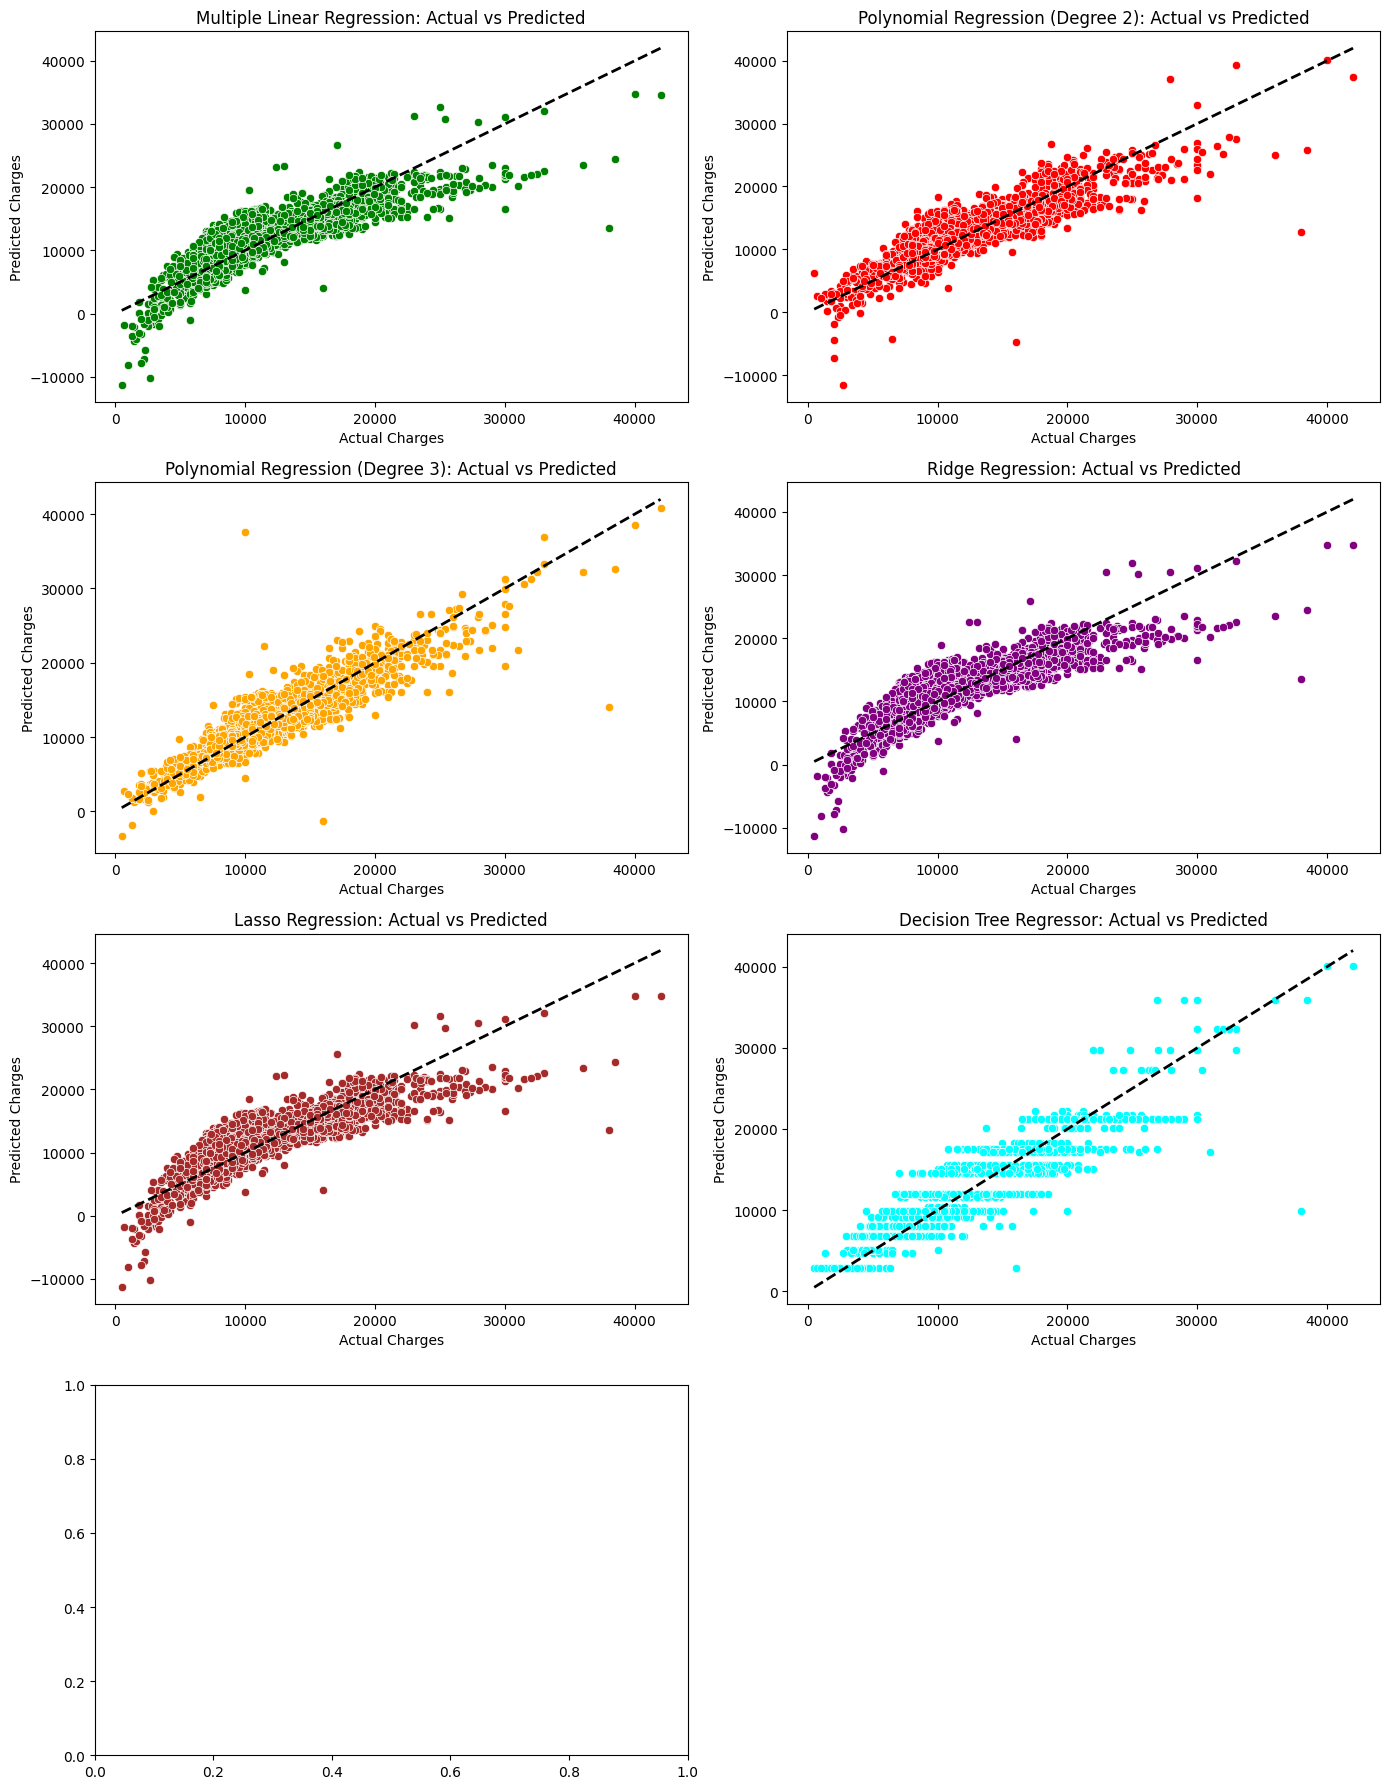

In [ ]:
# Create subplots (4 rows, 2 cols → 8 slots, we need 7) 
fig, axes = plt.subplots(4, 2, figsize=(14, 18)) 
axes = axes.flatten() 

 
# Models, predictions, and colors 
plots = [ 
("Multiple Linear Regression", y_pred_lr, "green"), 
("Polynomial Regression (Degree 2)", y_pred_poly2, "red"), 
("Polynomial Regression (Degree 3)", y_pred_poly3, "orange"), 
("Ridge Regression", y_pred_ridge, "purple"), 
("Lasso Regression", y_pred_lasso, "brown"), 
("Decision Tree Regressor", y_pred_dt, "cyan"), 
] 
 
# Plot each model 
for i, (title, preds, color) in enumerate(plots): 
    sns.scatterplot(x=y_test, y=preds, ax=axes[i], color=color) 
    axes[i].set_title(f"{title}: Actual vs Predicted") 
    axes[i].set_xlabel("Actual Charges") 
    axes[i].set_ylabel("Predicted Charges") 
    # Optional reference line (y=x) to check accuracy 
    min_val, max_val = y_test.min(), y_test.max() 
    axes[i].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2) 
 
# Remove the last empty subplot 
fig.delaxes(axes[-1]) 
 
plt.tight_layout() 
plt.show()

In [ ]:
# train model using XGBoost Regressor
import xgboost as xgb
xgbr = xgb.XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=None)
xgbr.fit(X_train, y_train)
y_pred_test_xgbr=xgbr.predict(X_test)
y_pred_train_xgbr = xgbr.predict(X_train)

mse=mean_squared_error(y_test,y_pred_test_xgbr)
RMSE=np.sqrt(mse)
r2=r2_score(y_test,y_pred_test_xgbr)
r2_train=r2_score(y_train,y_pred_train_xgbr)
mae=mean_absolute_error(y_test,y_pred_test_xgbr)
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {RMSE}')
print(f'R² (Test): {r2}')
print(f'R² (Train): {r2_train}')

MAE: 814.8742065429688
MSE: 1388221.625
RMSE: 1178.2281718750405
R² (Test): 0.9380591511726379
R² (Train): 0.9544392824172974


In [ ]:
#trying different alpha values for XGBoost Regressor
alphas=[0.01,0.1,1,10,100]
for alpha in alphas:
    xgbr = xgb.XGBRegressor(random_state=42, n_estimators=150, learning_rate=0.1, max_depth=None)
    xgbr.fit(X_train, y_train)
    y_pred_xgb = xgbr.predict(X_test)

    mse = mean_squared_error(y_test, y_pred_xgb)
    RMSE = np.sqrt(mse)
    r2=r2_score(y_test,y_pred_xgb)
    mae=mean_absolute_error(y_test,y_pred_xgb)
    
    print(f'Alpha: {alpha}')
    print(f'MAE: {mae}')
    print(f'MSE: {mse}')
    print(f'RMSE: {RMSE}')
    print(f'R²: {r2}\n')

Alpha: 0.01
MAE: 805.4317016601562
MSE: 1357959.75
RMSE: 1165.315300680464
R²: 0.9394093751907349

Alpha: 0.1
MAE: 805.4317016601562
MSE: 1357959.75
RMSE: 1165.315300680464
R²: 0.9394093751907349

Alpha: 1
MAE: 805.4317016601562
MSE: 1357959.75
RMSE: 1165.315300680464
R²: 0.9394093751907349

Alpha: 10
MAE: 805.4317016601562
MSE: 1357959.75
RMSE: 1165.315300680464
R²: 0.9394093751907349

Alpha: 100
MAE: 805.4317016601562
MSE: 1357959.75
RMSE: 1165.315300680464
R²: 0.9394093751907349



<Axes: xlabel='price'>

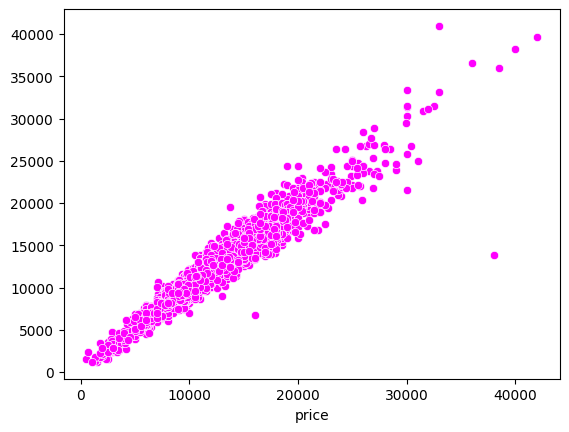

In [ ]:
#scatter plot for XGBoost Regressor
sns.scatterplot(x=y_test, y=y_pred_test_xgbr, color='magenta')